# Lecture 9 — Classification: Sigmoid, Logistic Regression & Neural Networks

**Practices covered:** L03 (Logistic Regression), L04 (Regularized), L05 (One-vs-All), L06–L07 (Neural Networks)

---

## Why Not Just Use Linear Regression for Classification?

Suppose you want to predict: *Will a student pass an exam?* (0 = fail, 1 = pass)

You could fit a line through (score, 0/1) data. But:
- The line outputs values like -0.3 or 1.7 — meaningless as probabilities
- It assumes a linear relationship between score and pass/fail, but the real relationship is an "S-curve"

What we actually want: a function that outputs **probabilities** (always between 0 and 1).

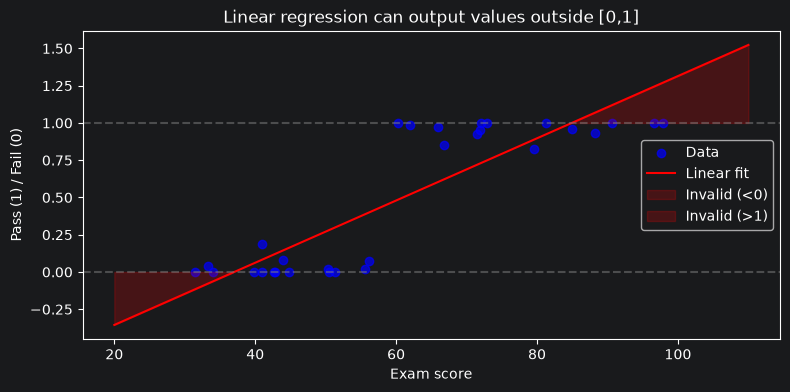

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Why linear regression fails for classification
np.random.seed(42)
scores = np.sort(np.random.uniform(30, 100, 30))
labels = (scores > 60).astype(float) + 0.1*np.random.randn(30)
labels = np.clip(labels, 0, 1)

# Fit linear regression
W_lin = np.polyfit(scores, labels, 1)
x_plot = np.linspace(20, 110, 200)
y_lin = np.polyval(W_lin, x_plot)

plt.figure(figsize=(9, 4))
plt.scatter(scores, labels, c='blue', alpha=0.7, label='Data')
plt.plot(x_plot, y_lin, 'r-', label='Linear fit')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.fill_between(x_plot, 0, y_lin, where=y_lin<0, alpha=0.2, color='red', label='Invalid (<0)')
plt.fill_between(x_plot, 1, y_lin, where=y_lin>1, alpha=0.2, color='red', label='Invalid (>1)')
plt.xlabel('Exam score'); plt.ylabel('Pass (1) / Fail (0)')
plt.title('Linear regression can output values outside [0,1]')
plt.legend(); plt.show()

## Part 1 — The Sigmoid Function: The S-Curve That Saves Us

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Why this function?** It has exactly the properties we need:

1. **Output always in (0, 1)** — interpretable as probability
2. **Smooth and differentiable** — gradient descent can optimize it
3. **Monotonically increasing** — higher $z$ = higher probability
4. **Saturates at extremes** — very high scores are confidently 1, very low are confidently 0
5. **Symmetric:** $\sigma(-z) = 1 - \sigma(z)$ — probability of class 1 and class 0 sum to 1

**What is $z$?** It's the output of a linear model: $z = w_0 + w_1 x_1 + w_2 x_2 + \ldots$

So: **linear model → sigmoid → probability**. That's logistic regression.

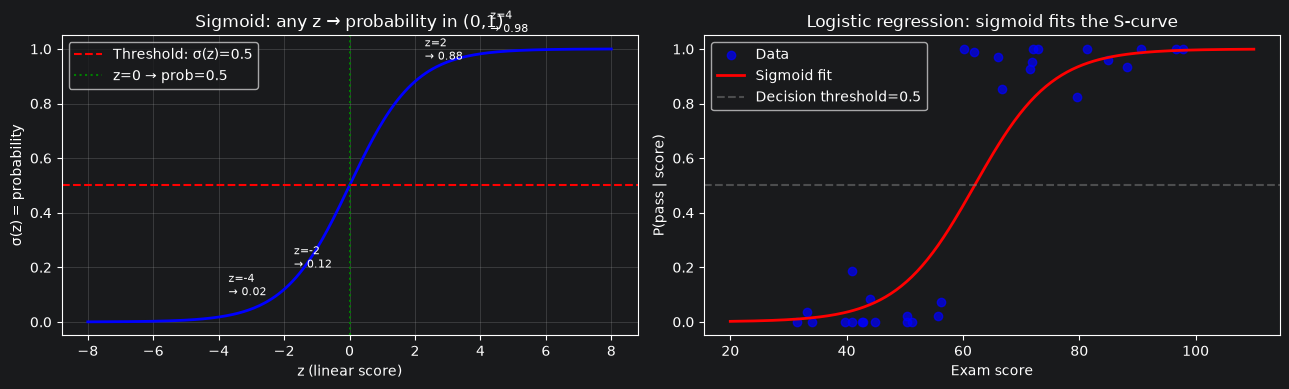

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.linspace(-8, 8, 300)
s = sigmoid(z)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: the sigmoid curve
axes[0].plot(z, s, 'b-', linewidth=2)
axes[0].axhline(0.5, color='r', linestyle='--', label='Threshold: σ(z)=0.5')
axes[0].axvline(0.0, color='g', linestyle=':', label='z=0 → prob=0.5')
for val, label in [(-4, '-4'), (-2, '-2'), (2, '2'), (4, '4')]:
    axes[0].annotate(f'z={label}\n→ {sigmoid(val):.2f}', xy=(val, sigmoid(val)),
                     xytext=(val+0.3, sigmoid(val)+0.08), fontsize=8)
axes[0].set_xlabel('z (linear score)'); axes[0].set_ylabel('σ(z) = probability')
axes[0].set_title('Sigmoid: any z → probability in (0,1)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Right: now fit sigmoid to classification data
axes[1].scatter(scores, labels, c='blue', alpha=0.7, label='Data')
# Fake logistic fit
axes[1].plot(x_plot, sigmoid(0.15*(x_plot - 62)), 'r-', linewidth=2, label='Sigmoid fit')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Decision threshold=0.5')
axes[1].set_xlabel('Exam score'); axes[1].set_ylabel('P(pass | score)')
axes[1].set_title('Logistic regression: sigmoid fits the S-curve')
axes[1].legend()

plt.tight_layout(); plt.show()

## Part 2 — Why Not Use MSE for Classification? Cross-Entropy Loss

If we use the MSE cost with sigmoid outputs, the optimization landscape has many local minima (non-convex). Gradient descent might get stuck.

**Cross-entropy loss** is derived from the likelihood of the data:

$$J(W) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]$$

**Why does this work?**

- When $y^{(i)} = 1$: cost = $-\log(\hat{y}^{(i)})$ → if $\hat{y}=0.99$, cost is tiny; if $\hat{y}=0.01$, cost is huge
- When $y^{(i)} = 0$: cost = $-\log(1-\hat{y}^{(i)})$ → penalizes predicting high probability for a negative example

**Key property:** Cross-entropy is **convex** with sigmoid output → gradient descent finds the global minimum.

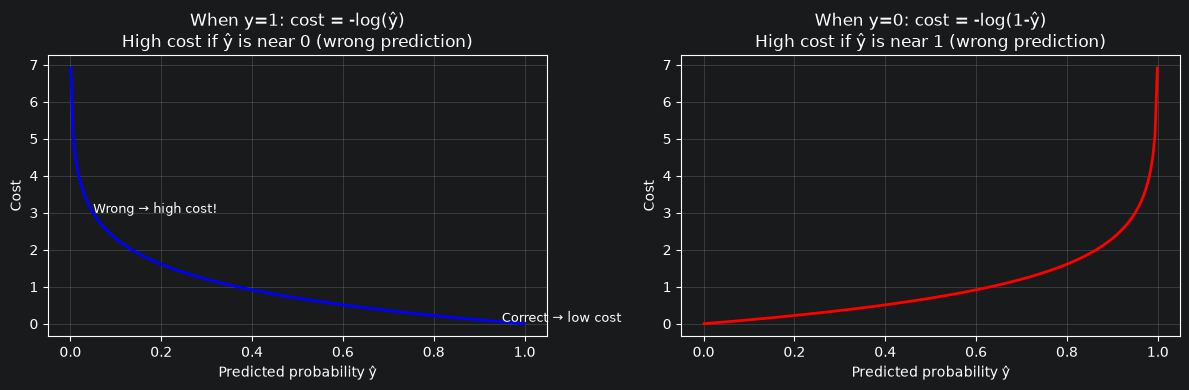

In [3]:
# Visualize: what cross-entropy penalizes
p = np.linspace(0.001, 0.999, 200)  # predicted probability

loss_y1 = -np.log(p)         # cost when true label y=1
loss_y0 = -np.log(1 - p)     # cost when true label y=0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(p, loss_y1, 'b-', linewidth=2)
axes[0].set_title('When y=1: cost = -log(ŷ)\nHigh cost if ŷ is near 0 (wrong prediction)')
axes[0].set_xlabel('Predicted probability ŷ'); axes[0].set_ylabel('Cost')
axes[0].annotate('Correct → low cost', xy=(0.95, -np.log(0.95)), fontsize=9)
axes[0].annotate('Wrong → high cost!', xy=(0.05, -np.log(0.05)), fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(p, loss_y0, 'r-', linewidth=2)
axes[1].set_title('When y=0: cost = -log(1-ŷ)\nHigh cost if ŷ is near 1 (wrong prediction)')
axes[1].set_xlabel('Predicted probability ŷ'); axes[1].set_ylabel('Cost')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [5]:
# Full logistic regression — exactly as in Practice L03
np.random.seed(42)
m = 100
X_pos = np.random.randn(m//2, 2) + np.array([2, 2])
X_neg = np.random.randn(m//2, 2) + np.array([-1, -1])
X_raw = np.vstack([X_pos, X_neg])
Y = np.array([1]*(m//2) + [0]*(m//2), dtype=float)
print(X_pos.shape, X_neg.shape, X_raw.shape)

# Normalize + add bias
mu = X_raw.mean(axis=0); sigma = X_raw.std(axis=0)
X_norm = (X_raw - mu) / sigma
X = np.column_stack((np.ones(m), X_norm))

def costFunction(w, X, Y):
    """Returns (cost, gradient) — note w is 1D here."""
    h = sigmoid(X @ w)                        # (m,)
    m = len(Y)
    C = (1/m) * np.sum(-Y * np.log(h+1e-8) - (1-Y) * np.log(1-h+1e-8))
    grad = X.T @ (h - Y) / m                  # (3,)
    return C, grad

def gradientDescent(X, Y, w, lr, num_iters):
    C_history = []
    for _ in range(num_iters):
        C, grad = costFunction(w, X, Y)
        w = w - lr * grad
        C_history.append(C)
    return w, np.array(C_history)

w_init = np.zeros(3)
w_opt, costs = gradientDescent(X, Y, w_init, lr=1.0, num_iters=500)

predictions = (sigmoid(X @ w_opt) >= 0.5)
accuracy = np.mean(predictions == Y) * 100
print(f"Training accuracy: {accuracy:.1f}%")
print(f"Final cost: {costs[-1]:.4f}")

(50, 2) (50, 2) (100, 2)
Training accuracy: 100.0%
Final cost: 0.0162


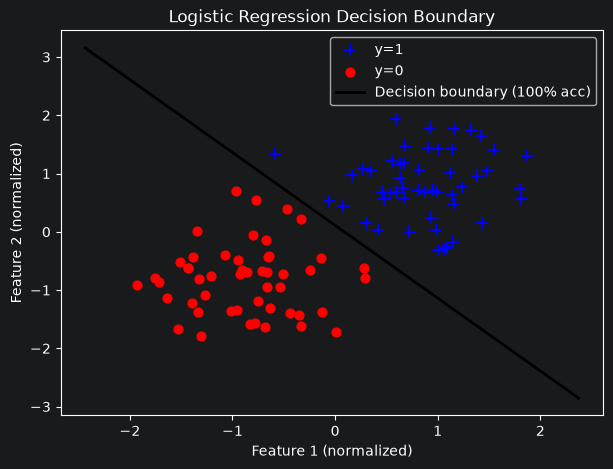

In [6]:
# Plot decision boundary
x1_range = np.linspace(X_norm[:,0].min()-0.5, X_norm[:,0].max()+0.5, 100)
# Boundary: w0 + w1*x1 + w2*x2 = 0 → x2 = -(w0 + w1*x1)/w2
x2_boundary = -(w_opt[0] + w_opt[1]*x1_range) / w_opt[2]

plt.figure(figsize=(7, 5))
plt.scatter(X_norm[Y==1, 0], X_norm[Y==1, 1], c='blue', marker='+', s=80, label='y=1')
plt.scatter(X_norm[Y==0, 0], X_norm[Y==0, 1], c='red',  marker='o', s=40, label='y=0')
plt.plot(x1_range, x2_boundary, 'k-', linewidth=2, label=f'Decision boundary ({accuracy:.0f}% acc)')
plt.xlabel('Feature 1 (normalized)'); plt.ylabel('Feature 2 (normalized)')
plt.title('Logistic Regression Decision Boundary')
plt.legend(); plt.show()

## Part 3 — Non-linear Boundaries: Polynomial Features + Regularization

What if the data is not linearly separable? (Practice L04)

**Solution:** Create polynomial features from the raw features, then apply logistic regression.

Instead of: $z = w_0 + w_1 x_1 + w_2 x_2$

Use: $z = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_1^2 + w_4 x_1 x_2 + w_5 x_2^2 + \ldots$

More features = more flexible boundary, but also more risk of overfitting. **Regularization** is essential here.

In [9]:
# Generate non-linearly separable data (circle pattern)
np.random.seed(0)
theta = np.random.uniform(0, 2*np.pi, 100)
r_pos = np.random.uniform(0, 1, 50)
r_neg = np.random.uniform(1.5, 2.5, 50)

X1 = np.column_stack([r_pos*np.cos(theta[:50]), r_pos*np.sin(theta[:50])])
X0 = np.column_stack([r_neg*np.cos(theta[50:]), r_neg*np.sin(theta[50:])])
X_circ = np.vstack([X1, X0])
Y_circ = np.array([1]*50 + [0]*50, dtype=float)

def mapFeature(X1, X2, deg=6):
    """Polynomial features from two inputs — exactly as in Practice L04."""
    m = len(X1)
    out = [np.ones(m)]
    for i in range(1, deg+1):
        for j in range(i+1):
            out.append((X1**(i-j)) * (X2**j))
    return np.column_stack(out)

X_poly = mapFeature(X_circ[:,0], X_circ[:,1], deg=6)  # 28 features!
print(f"Original features: {X_circ.shape[1]} → Polynomial features: {X_poly.shape[1]}")

[0.67781654 0.27000797 0.73519402 0.96218855 0.24875314 0.57615733
 0.59204193 0.57225191 0.22308163 0.95274901 0.44712538 0.84640867
 0.69947928 0.29743695 0.81379782 0.39650574 0.8811032  0.58127287
 0.88173536 0.69253159 0.72525428 0.50132438 0.95608363 0.6439902
 0.42385505 0.60639321 0.0191932  0.30157482 0.66017354 0.29007761
 0.61801543 0.4287687  0.13547406 0.29828233 0.56996491 0.59087276
 0.57432525 0.65320082 0.65210327 0.43141844 0.8965466  0.36756187
 0.43586493 0.89192336 0.80619399 0.70388858 0.10022689 0.91948261
 0.7142413  0.99884701]
Original features: 2 → Polynomial features: 28


C:\Users\I779652\AppData\Local\Temp\ipykernel_25144\1198645713.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))


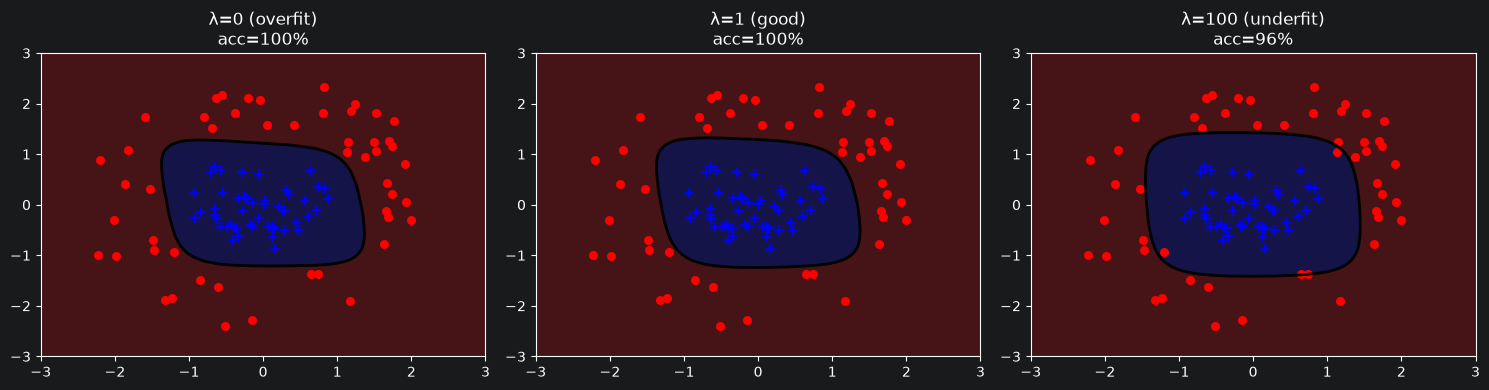

In [11]:
def costFunctionReg(w, X, Y, lam=1.0):
    m = len(Y)
    h = sigmoid(X @ w)
    C = (1/m) * np.sum(-Y*np.log(h+1e-8) - (1-Y)*np.log(1-h+1e-8))
    C += (lam/(2*m)) * np.sum(w[1:]**2)   # regularize all weights except bias
    grad = X.T @ (h - Y) / m
    grad[1:] += (lam/m) * w[1:]
    return C, grad

def train_regularized(X, Y, lam, epochs=1000, lr=0.1):
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        C, grad = costFunctionReg(w, X, Y, lam)
        w -= lr * grad
    return w

# Compare decision boundaries for different lambda
xx, yy = np.meshgrid(np.linspace(-3, 3, 80), np.linspace(-3, 3, 80))
X_grid = mapFeature(xx.ravel(), yy.ravel(), deg=6)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, lam, title in zip(axes, [0, 1, 100], ['λ=0 (overfit)', 'λ=1 (good)', 'λ=100 (underfit)']):
    w = train_regularized(X_poly, Y_circ, lam)
    probs = sigmoid(X_grid @ w).reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.2, colors=['red','blue'])
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X1[:,0], X1[:,1], c='blue', marker='+', s=60)
    ax.scatter(X0[:,0], X0[:,1], c='red',  marker='o', s=30)
    acc = np.mean((sigmoid(X_poly @ w) >= 0.5) == Y_circ.astype(bool)) * 100
    ax.set_title(f'{title}\nacc={acc:.0f}%')

plt.tight_layout(); plt.show()

## Part 4 — Multi-class: One-vs-All (Practice L05)

Logistic regression outputs a binary yes/no. For 10 digit classes (MNIST):

**One-vs-All strategy:**
1. Train 10 separate binary classifiers: "Is this a 0? Is this a 1? ... Is this a 9?"
2. Each classifier gets: positive examples = images of that digit, negative = all others
3. For prediction: run all 10 classifiers, pick the class with highest probability

Why this works: Each classifier learns "what makes digit $k$ special compared to everything else".

In [ ]:
# One-vs-All — exactly as in Practice L05
from sklearn.datasets import load_digits

digits = load_digits()  # 8x8 digits, 10 classes
X_dig = digits.data / 16.0  # normalize [0,1]
Y_dig = digits.target

m_dig, n_dig = X_dig.shape
X_dig_bias = np.hstack([np.ones((m_dig, 1)), X_dig])  # add bias

def oneVsAll(X, Y, num_labels, lam=0.1, lr=0.5, epochs=100):
    n = X.shape[1]
    w_all = np.zeros((num_labels, n))  # one row per class
    
    for k in range(num_labels):
        Y_k = (Y == k).astype(float)   # 1 for class k, 0 for all others
        w = np.zeros(n)
        for _ in range(epochs):
            _, grad = costFunctionReg(w, X, Y_k, lam)
            w -= lr * grad
        w_all[k] = w
        
    return w_all

print("Training One-vs-All (10 classifiers)...")
w_all = oneVsAll(X_dig_bias, Y_dig, num_labels=10, lam=0.1, lr=0.5, epochs=100)

# Predict: compute all 10 probabilities, take argmax
probs = sigmoid(X_dig_bias @ w_all.T)  # (m, 10)
predictions = probs.argmax(axis=1)      # class with highest probability
accuracy = np.mean(predictions == Y_dig) * 100
print(f"One-vs-All accuracy: {accuracy:.1f}%")

## Part 5 — Neural Networks: Stacking Logistic Units

One-vs-All with logistic regression can only learn **linear** decision boundaries per class. MNIST digits are not linearly separable.

**Neural network:** chain multiple logistic regression layers together.

$$\text{Layer 1: } a^{(1)} = \sigma(X W^{(1)})$$
$$\text{Layer 2: } \hat{y} = \sigma(a^{(1)} W^{(2)})$$

Each layer learns intermediate "features" that are nonlinear combinations of the raw input. The second layer then does logistic regression on those learned features.

**Why does adding layers help?**
- Layer 1 detects simple patterns: edges, curves, stroke directions
- Layer 2 combines those into digit-specific patterns: loops for 0, verticals for 1, etc.
- Exponentially more powerful than a single linear classifier

In [ ]:
# Neural network forward pass — exactly as in Practice L06
def sigmoid_gradient(z):
    s = sigmoid(z)
    return s * (1 - s)

def predict_nn(X, w1, w2):
    """
    X:  (m, input_size)          — input features
    w1: (hidden, input_size+1)   — weights for hidden layer
    w2: (output, hidden+1)       — weights for output layer
    Returns: predicted class (m,)
    """
    m = X.shape[0]
    # Layer 1
    a1 = np.hstack([np.ones((m, 1)), X])   # add bias: (m, input+1)
    s2 = a1 @ w1.T                          # (m, hidden)
    a2 = sigmoid(s2)                        # (m, hidden)
    # Layer 2
    a2_b = np.hstack([np.ones((m, 1)), a2]) # add bias: (m, hidden+1)
    s3 = a2_b @ w2.T                        # (m, output)
    a3 = sigmoid(s3)                        # (m, output)
    return np.argmax(a3, axis=1)            # class with highest probability

# Train with backpropagation
def train_nn(X, Y, hidden_size=25, num_labels=10, lr=0.3, epochs=200, lam=0.1):
    m, n = X.shape
    # Random weight initialization (key: NOT zeros — all neurons would learn same thing)
    eps = 0.12
    w1 = np.random.rand(hidden_size, n + 1) * 2*eps - eps       # (25, input+1)
    w2 = np.random.rand(num_labels, hidden_size + 1) * 2*eps - eps  # (10, 26)
    
    # One-hot encode labels
    Y_oh = np.zeros((m, num_labels))
    Y_oh[np.arange(m), Y] = 1
    
    costs = []
    for epoch in range(epochs):
        # FORWARD PASS
        a1 = np.hstack([np.ones((m, 1)), X])
        s2 = a1 @ w1.T; a2 = sigmoid(s2)
        a2_b = np.hstack([np.ones((m, 1)), a2])
        s3 = a2_b @ w2.T; a3 = sigmoid(s3)
        
        # COST
        cost = -(1/m) * np.sum(Y_oh*np.log(a3+1e-8) + (1-Y_oh)*np.log(1-a3+1e-8))
        cost += (lam/(2*m)) * (np.sum(w1[:,1:]**2) + np.sum(w2[:,1:]**2))
        costs.append(cost)
        
        # BACKWARD PASS (backpropagation)
        # Output layer error
        delta3 = (a3 - Y_oh) * sigmoid_gradient(s3)            # (m, 10)
        # Hidden layer error (backpropagate through w2, skip bias column)
        delta2 = (delta3 @ w2)[:, 1:] * sigmoid_gradient(s2)   # (m, 25)
        # Gradients
        dw2 = (1/m) * delta3.T @ a2_b   # (10, 26)
        dw1 = (1/m) * delta2.T @ a1     # (25, input+1)
        # Regularization (skip bias column)
        dw2[:, 1:] += (lam/m) * w2[:, 1:]
        dw1[:, 1:] += (lam/m) * w1[:, 1:]
        # Update
        w1 -= lr * dw1
        w2 -= lr * dw2
    
    return w1, w2, costs

print("Training neural network (2 layers)...")
np.random.seed(0)
w1, w2, nn_costs = train_nn(X_dig, Y_dig, hidden_size=25, epochs=300, lr=0.5, lam=0.1)
nn_preds = predict_nn(X_dig, w1, w2)
nn_accuracy = np.mean(nn_preds == Y_dig) * 100
print(f"Neural network accuracy: {nn_accuracy:.1f}%  (vs One-vs-All: {accuracy:.1f}%)")

## Part 6 — Why Backpropagation? The Chain Rule

Backpropagation is just the **chain rule of calculus** applied to a composition of functions.

Forward: $x \rightarrow z^{(2)} \rightarrow a^{(2)} \rightarrow z^{(3)} \rightarrow a^{(3)} \rightarrow J$

Backward (chain rule):
$$\frac{\partial J}{\partial W^{(1)}} = \frac{\partial J}{\partial a^{(3)}} \cdot \frac{\partial a^{(3)}}{\partial z^{(3)}} \cdot \frac{\partial z^{(3)}}{\partial a^{(2)}} \cdot \frac{\partial a^{(2)}}{\partial z^{(2)}} \cdot \frac{\partial z^{(2)}}{\partial W^{(1)}}$$

This is computed layer by layer from output to input — hence "backward propagation".

**Why the sigmoid gradient $\sigma(z)(1-\sigma(z))$ appears:**
$\frac{\partial a^{(l)}}{\partial z^{(l)}} = \sigma'(z^{(l)}) = \sigma(z^{(l)})(1 - \sigma(z^{(l)}))$

In [ ]:
# Visualize what the hidden layer learned
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat[:25]):
    # Each row of w1 = weights from input to one hidden neuron
    # Reshape to 8x8 to visualize as an image
    neuron_weights = w1[i, 1:]  # skip bias
    ax.imshow(neuron_weights.reshape(8, 8), cmap='RdBu', vmin=-abs(neuron_weights).max(), vmax=abs(neuron_weights).max())
    ax.axis('off')

plt.suptitle('What each of the 25 hidden neurons "looks for"\n(red=positive weight, blue=negative)', y=1.02)
plt.tight_layout()
plt.show()

## Part 7 — Performance Metrics: Beyond Accuracy

For the spam filter and real problems, accuracy alone is misleading.

Suppose 95% of emails are ham. A classifier that always says "ham" gets 95% accuracy — but catches zero spam!

**Confusion Matrix:**
```
                  Predicted Positive  Predicted Negative
Actual Positive:       TP                  FN
Actual Negative:       FP                  TN
```

**Better metrics:**
- **Precision** = TP / (TP + FP) — "of all predicted spam, how many actually were spam?"
- **Recall** = TP / (TP + FN) — "of all actual spam, how many did we catch?"
- **F1** = 2 × Precision × Recall / (Precision + Recall) — harmonic mean
- **AUC-ROC** — area under the ROC curve; 1.0 = perfect, 0.5 = random

In [ ]:
# Demonstrate the tradeoff: high precision vs high recall
from sklearn.metrics import precision_score, recall_score, f1_score

# True labels: 20 spam (1), 80 ham (0)
np.random.seed(1)
y_true = np.array([1]*20 + [0]*80)

# Scenario A: very strict (only flags very obvious spam)
y_strict = np.zeros(100); y_strict[[5, 8, 12]] = 1  # catches 3/20 spam, no false alarms

# Scenario B: aggressive (flags anything suspicious)
y_aggressive = np.ones(100); y_aggressive[50:80] = 0  # catches 20/20 spam, many false alarms

# Scenario C: balanced
y_balanced = np.zeros(100)
y_balanced[:20] = np.random.rand(20) > 0.2  # catches 80% spam
y_balanced[20:] = np.random.rand(80) < 0.05  # 5% false positive rate

print("                 Accuracy  Precision  Recall  F1")
print("-" * 55)
for name, y_pred in [('Strict   ', y_strict), ('Aggressive', y_aggressive), ('Balanced  ', y_balanced)]:
    acc = np.mean(y_pred == y_true)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"{name}:   {acc:.2f}       {p:.2f}      {r:.2f}    {f1:.2f}")

---
## Summary — The Classification Stack

```
Raw features  →  [optional: polynomial features]  →  linear combination (z = Xw)
     ↓
Sigmoid activation σ(z) → probability in (0,1)
     ↓
Cross-entropy loss → gradient descent → learn weights w
     ↓
Threshold at 0.5 → binary prediction
```

**Neural network = multiple layers of this stack.**

**Why sigmoid and not something else?**
- Outputs probabilities (bounded 0–1)
- Differentiable everywhere (needed for backprop)
- Its derivative $\sigma'(z) = \sigma(z)(1-\sigma(z))$ is simple and depends only on the output
- Makes the cross-entropy gradient clean: $\nabla_W J = X^T(\hat{y} - y)$

**Why cross-entropy and not MSE?**
- MSE with sigmoid is non-convex → local minima
- Cross-entropy is convex with sigmoid → global minimum guaranteed
- Cross-entropy directly maximizes the likelihood of the observed labels

**Next:** [L10_dimension_reduction.ipynb](L10_dimension_reduction.ipynb) — PCA and eigendecomposition.